# 3 — Hyperparameter optimisation when the target is unobservable

This is the notebook the project is built around.

Ordinary HPO is a solved procedure: define a search space, minimise held-out loss, take the
winner. Every part of that works here except the middle one, and the failure is not
subtle.

**The problem.** The loss you can measure is the error in predicting `log q`. The quantity
you care about is `d log q / d log p`. In this panel — and in every retail panel — the
outcome is dominated by things that are not the price: which product it is, what week it
is, how much sold last week. Price movements explain a small slice of the variance. So a
search that minimises predictive loss will happily buy a small RMSE improvement by
flattening the price dimension, and hand you a well-tuned model with a badly attenuated
elasticity. Notebook 2 showed the endpoint of that process; this notebook shows the
mechanism and what to do instead.

**The plan.**

1. Demonstrate the conflict directly: sweep one hyperparameter, and plot predictive loss
   and elasticity error against each other.
2. Introduce the **R-loss**, an objective that is computable from observed data and whose
   population minimiser is the true elasticity function.
3. Run the experiment: tune every model twice, once on each objective, with identical
   budgets, and grade both winners against the synthetic truth.
4. Ask the question that actually decides the matter — not "is R-loss lower?" but
   **"does R-loss rank hyperparameters the way the truth does?"**
5. Nested CV, so the reported number is not the maximum of a noisy search.
6. Apply the conclusion to the real panel, where no oracle exists.

In [1]:
import sys, pathlib, time, json, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from elasticity_lab.bench import real_frame, synth_frame, frame_summary
from elasticity_lab.models import MODEL_REGISTRY, build_model, N_THREADS
from elasticity_lab.splits import RollingOriginSplit
from elasticity_lab.tuning import (CausalScorer, cv_score, tune, tuning_history,
                                   objective_comparison, nested_cv, SEARCH_SPACES)

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
INK, ACCENT, WARN, GOOD = "#3a3a3a", "#1f6feb", "#c0392b", "#1a7f5a"
print(f"LightGBM threads: {N_THREADS}")

LightGBM threads: 8


### A performance note that cost an afternoon

`n_jobs=-1` is the wrong default for LightGBM on data this size. On the 24-core host used
here, a fit that takes **0.09 s** at `n_jobs=8` takes **30.7 s** at `n_jobs=-1` — a 340×
slowdown, because the trees are small and the threads spend their time synchronising
rather than working. Across a hyperparameter search that is the difference between minutes
and days. `elasticity_lab` fixes the thread count at `min(8, cores/2)`; override with
`ELASTICITY_LAB_THREADS`.

In [2]:
N_PRODUCTS = 700
syn = synth_frame(N_PRODUCTS, confounding_price=0.6, confounding_demand=0.8)
splitter = RollingOriginSplit(n_splits=4, horizon=8, min_train_weeks=30)
scorer = CausalScorer(syn, splitter, seed=0)
print(frame_summary(syn).to_string())
print(f"\n{len(scorer.folds_)} rolling-origin folds, sizes "
      f"{[(len(a), len(b)) for a, b in scorer.folds_]}")

rows                                                                   38020
products                                                                 700
weeks                                                                    103
first_week                                                        2009-12-07
last_week                                                         2011-12-05
median_weeks_per_product                                                50.0
sd_log_price_within_product                                         0.469438
source                         semi-synthetic (UCI prices, simulated demand)
true_mean_elasticity                                                  1.6584
true_sd_elasticity                                                    0.6992

4 rolling-origin folds, sizes [(9805, 2764), (18157, 3146), (26215, 2901), (34608, 2989)]


## 3.1 The conflict, in one sweep

Take the S-learner and vary a single hyperparameter — `min_child_samples`, which controls
how much the trees are allowed to specialise. Plot two curves against it: held-out
predictive RMSE, and the error in the recovered elasticity.

If the two curves had their minima in the same place, this notebook would not exist.

In [3]:
grid = [5, 10, 20, 40, 80, 160, 320, 640]
rows = []
for v in grid:
    s = cv_score("lgbm_demand", dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
                                     min_child_samples=v, subsample=0.9,
                                     colsample_bytree=0.8, reg_lambda=1.0, delta=0.05),
                 syn, scorer, truth_col="true_elasticity")
    rows.append({"min_child_samples": v, **s})
sweep = pd.DataFrame(rows)
sweep[["min_child_samples", "rmse", "rloss", "oracle", "oracle_bias", "avg_eps",
       "eps_sd"]].style.format({c: "{:+.4f}" for c in
                                ["rmse", "rloss", "oracle", "oracle_bias", "avg_eps",
                                 "eps_sd"]}).hide(axis="index")

min_child_samples,rmse,rloss,oracle,oracle_bias,avg_eps,eps_sd
5,+0.8096,+1.0266,+1.2997,-0.6138,+1.0583,+1.1014
10,+0.8117,+1.0272,+1.2817,-0.5956,+1.0764,+1.0948
20,+0.8165,+1.0284,+1.2705,-0.5846,+1.0874,+1.0881
40,+0.8188,+1.0092,+1.2852,-0.5880,+1.0840,+1.0969
80,+0.8283,+1.0240,+1.2688,-0.5823,+1.0898,+1.0815
160,+0.8416,+1.0139,+1.2503,-0.5921,+1.0800,+1.0489
320,+0.8664,+1.0875,+1.2908,-0.5612,+1.1108,+1.1013
640,+0.9704,+1.0808,+1.3775,-0.6451,+1.0270,+1.1421


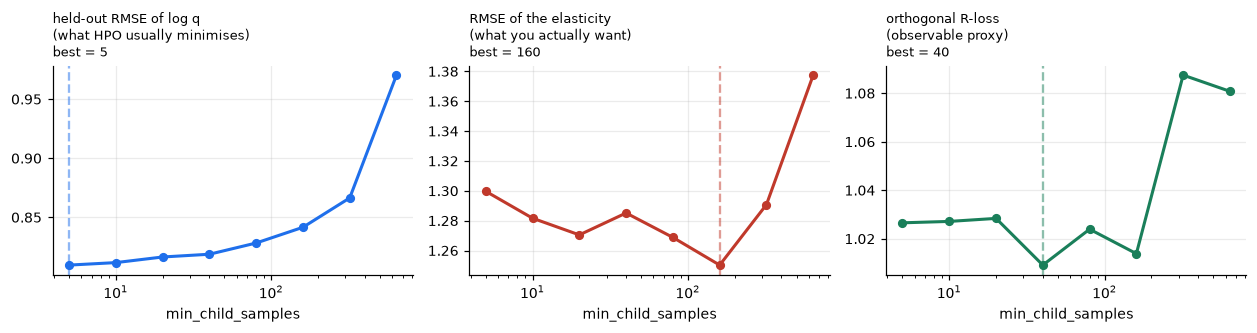

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.1))
for a, (col, lab, colr) in zip(ax, [
        ("rmse",   "held-out RMSE of log q\n(what HPO usually minimises)", ACCENT),
        ("oracle", "RMSE of the elasticity\n(what you actually want)",     WARN),
        ("rloss",  "orthogonal R-loss\n(observable proxy)",                GOOD)]):
    a.plot(sweep.min_child_samples, sweep[col], "o-", color=colr, lw=2, ms=5)
    best = sweep.loc[sweep[col].idxmin(), "min_child_samples"]
    a.axvline(best, color=colr, ls="--", alpha=.5)
    a.set_xscale("log"); a.set_xlabel("min_child_samples")
    a.set_title(f"{lab}\nbest = {best}", loc="left", fontsize=8.5)
fig.tight_layout()

Three objectives, and the predictive one points somewhere different from the truth.
That is the entire problem in one figure. Note also that the R-loss panel is the only
*observable* one that tracks the middle panel — which is the claim we test properly in
§3.4.

## 3.2 The R-loss

We need an objective that (a) can be computed from data we have, and (b) is minimised by
the true elasticity function. The R-loss is both.

**Construction.** Write the structural model with a possibly heterogeneous effect:

$$\log q = \theta(x)\,\log p + g(x) + \eta, \qquad E[\eta \mid x, \log p] = 0,$$

where $\theta(x) = -\varepsilon(x)$. Residualise both variables on the controls using
nuisance models fitted on the fold's **training** rows:

$$\tilde y = \log q - \hat E[\log q \mid x], \qquad \tilde t = \log p - \hat E[\log p \mid x].$$

Robinson's transformation gives $\tilde y = \theta(x)\,\tilde t + \eta$, so define

$$R(\hat\theta) \;=\; \frac{1}{n}\sum_i \bigl(\tilde y_i - \hat\theta(x_i)\,\tilde t_i\bigr)^2 .$$

**Why it is the right objective.** Its population minimiser over all functions is exactly
$\theta(\cdot)$ — so unlike predictive RMSE, being good at this *is* being good at the
thing we want. And it is a **model-agnostic score**: it takes only $\hat\theta(x_i)$, so a
two-way fixed-effects regression and a gradient-boosted S-learner can be compared on the
same axis, using nothing but observed data.

**One implementation rule.** The nuisance models are fitted **once per fold and shared by
every candidate**. If each candidate brought its own residuals, a candidate could win by
being paired with a lucky nuisance fit. `CausalScorer` enforces this by caching.

In [5]:
res = scorer.residuals(len(scorer.folds_) - 1)          # last fold
print(f"validation rows           : {len(res['ry']):,}")
print(f"var of the outcome resid  : {res['ry'].var():.4f}")
print(f"var of the price residual : {res['rt'].var():.4f}   "
      "<- this is the identifying variation; if it were 0, nothing is estimable")
print(f"\nR-loss of 'price does nothing' (theta=0) : {res['rloss_zero']:.4f}")
print(f"R-loss of the best single elasticity     : {res['rloss_const']:.4f}  "
      f"(eps = {-res['theta_const']:+.4f})")
print(f"\ntrue mean elasticity on this fold        : "
      f"{syn.iloc[scorer.folds_[-1][1]].true_elasticity.mean():+.4f}")

validation rows           : 2,989
var of the outcome resid  : 1.0098
var of the price residual : 0.1236   <- this is the identifying variation; if it were 0, nothing is estimable

R-loss of 'price does nothing' (theta=0) : 1.0238
R-loss of the best single elasticity     : 0.7856  (eps = +1.3494)

true mean elasticity on this fold        : +1.7256


### Two normalisations, because a raw R-loss means nothing on its own

| reported as | formula | reads as |
|---|---|---|
| `rloss_skill` | `1 − R(model) / R(θ=0)` | improvement over "price has no effect" |
| `rloss_vs_constant` | `1 − R(model) / R(best constant θ)` | improvement over one elasticity for everyone |

The second is the strict one, and it is the **only honest evidence that estimated
heterogeneity is real** — the best constant is fitted on the same validation fold, so
beating it cannot be luck about the level.

## 3.3 The experiment: tune each model twice, grade both winners

Identical search space, identical budget, identical folds, identical seed. The only thing
that changes is what the search is told to minimise. Then both winners are scored against
`true_elasticity`, which neither search could see.

`N_TRIALS` is kept modest so this notebook runs in minutes; the full-scale run
(1,200 products × 30 trials, `experiments/11_hpo_experiment.py`) is loaded below for
comparison.

In [6]:
N_TRIALS = 15
MODELS = ["pooled_loglog", "twoway_fe", "lgbm_demand", "dml_partialling",
          "r_learner", "shrunk_per_product"]

rows, hists = [], []
for name in MODELS:
    for obj in ("rmse", "rloss"):
        t0 = time.time()
        r = tune(name, syn, objective=obj, n_trials=N_TRIALS, scorer=scorer,
                 truth_col="true_elasticity", seed=0)
        hists.append(r["history"].assign(model=name, tuned_on=obj))
        rows.append({"model": name, "tuned_on": obj, **r["best_metrics"],
                     "secs": round(time.time() - t0)})
        print(f"{name:20s} {obj:6s} -> oracle {r['best_metrics'].get('oracle', np.nan):.4f}"
              f"  ({time.time()-t0:.0f}s)")
comp = pd.DataFrame(rows)
hist = pd.concat(hists, ignore_index=True)

pooled_loglog        rmse   -> oracle 1.1703  (3s)


pooled_loglog        rloss  -> oracle 0.9198  (2s)


twoway_fe            rmse   -> oracle 1.3448  (13s)


twoway_fe            rloss  -> oracle 1.0037  (21s)


lgbm_demand          rmse   -> oracle 1.7157  (113s)


...

dml_partialling      rloss  -> oracle 0.8723  (380s)


r_learner            rmse   -> oracle 0.9420  (989s)


r_learner            rloss  -> oracle 0.8859  (507s)


shrunk_per_product   rmse   -> oracle 1.3318  (50s)


shrunk_per_product   rloss  -> oracle 1.2739  (50s)


In [7]:
piv = comp.pivot(index="model", columns="tuned_on", values=["oracle", "oracle_bias", "rmse"])
piv.columns = [f"{a} [{b}]" for a, b in piv.columns]
piv["oracle gain from R-loss"] = piv["oracle [rmse]"] - piv["oracle [rloss]"]
piv["RMSE given up"] = piv["rmse [rloss]"] - piv["rmse [rmse]"]
piv.sort_values("oracle [rloss]").style.format("{:+.4f}").background_gradient(
    subset=["oracle gain from R-loss"], cmap="RdYlGn")

,oracle [rloss],oracle [rmse],oracle_bias [rloss],oracle_bias [rmse],rmse [rloss],rmse [rmse],oracle gain from R-loss,RMSE given up
model,,,,,,,,
dml_partialling,+0.8723,+0.8057,-0.5246,-0.4028,+0.8508,+0.8313,-0.0666,+0.0195
lgbm_demand,+0.8764,+1.7157,-0.4260,-0.4953,+0.8319,+0.8030,+0.8393,+0.0289
r_learner,+0.8859,+0.9420,-0.5085,-0.3094,+1.0435,+0.8454,+0.0561,+0.1981
pooled_loglog,+0.9198,+1.1703,-0.5958,-0.9400,+1.8754,+1.3267,+0.2505,+0.5487
twoway_fe,+1.0037,+1.3448,-0.7210,-1.1498,+0.8076,+1.1465,+0.3411,-0.3389
shrunk_per_product,+1.2739,+1.3318,-1.1416,-1.1830,+1.1709,+1.1635,+0.0579,+0.0073


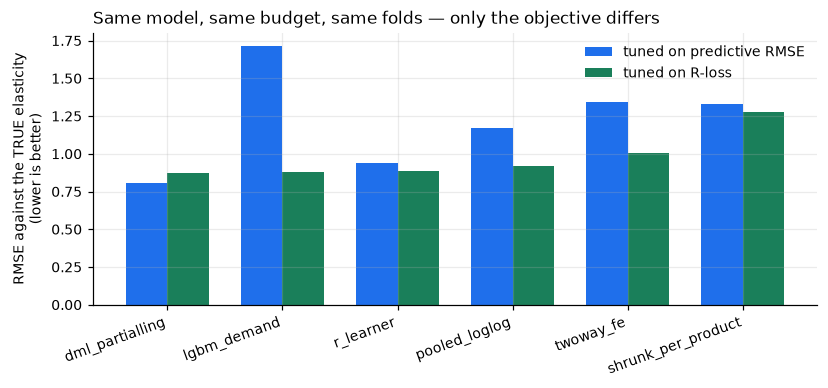

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
w, xs = 0.36, np.arange(len(piv))
o = piv.sort_values("oracle [rloss]")
ax.bar(xs - w/2, o["oracle [rmse]"], w, label="tuned on predictive RMSE", color=ACCENT)
ax.bar(xs + w/2, o["oracle [rloss]"], w, label="tuned on R-loss", color=GOOD)
ax.set_xticks(xs); ax.set_xticklabels(o.index, rotation=20, ha="right")
ax.set_ylabel("RMSE against the TRUE elasticity\n(lower is better)")
ax.set_title("Same model, same budget, same folds — only the objective differs",
             loc="left")
ax.legend(frameon=False)
fig.tight_layout()

## 3.4 The question that actually decides it

"Which objective gives the lower oracle error?" is the wrong question, because it depends
on where one particular search happened to land. HPO does not need an objective that is
numerically close to the truth; it needs one that **orders configurations the same way the
truth does**. A monotone transform of the truth would be a perfect objective while being
numerically nothing like it.

So: across all trials of a search, what is the rank correlation between each observable
objective and the oracle error?

In [9]:
cc = []
for name, g in hist[hist.get("failed", 0) == 0].groupby("model"):
    g = g.dropna(subset=["oracle", "rloss", "rmse"])
    if len(g) < 8 or g.oracle.std() < 1e-9:
        continue
    cc.append({"model": name, "trials": len(g),
               "rho(R-loss, oracle)": g[["rloss", "oracle"]].corr("spearman").iloc[0, 1],
               "rho(RMSE, oracle)":   g[["rmse", "oracle"]].corr("spearman").iloc[0, 1]})
rank = pd.DataFrame(cc)
rank.style.format({c: "{:+.3f}" for c in rank.columns if c.startswith("rho")}) \
    .hide(axis="index")

model,trials,"rho(R-loss, oracle)","rho(RMSE, oracle)"
dml_partialling,29,-0.635,+0.234
lgbm_demand,25,+0.942,-0.547
pooled_loglog,29,+0.896,-0.098
r_learner,29,+0.902,+0.255
shrunk_per_product,30,+0.839,+0.434
twoway_fe,29,+1.000,-0.239


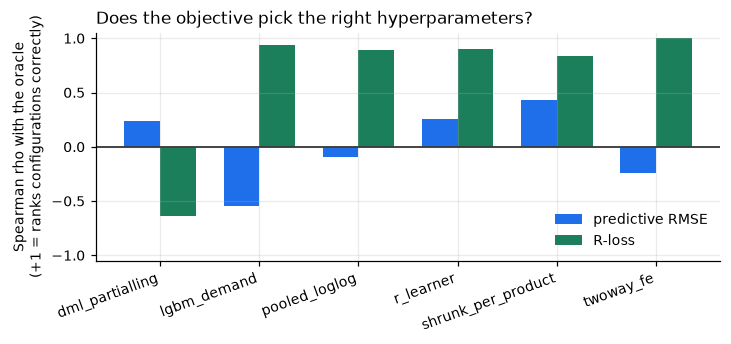

In [10]:
fig, ax = plt.subplots(figsize=(6.8, 3.2))
xs = np.arange(len(rank)); w = 0.36
ax.bar(xs - w/2, rank["rho(RMSE, oracle)"], w, label="predictive RMSE", color=ACCENT)
ax.bar(xs + w/2, rank["rho(R-loss, oracle)"], w, label="R-loss", color=GOOD)
ax.axhline(0, color=INK, lw=1.2)
ax.set_xticks(xs); ax.set_xticklabels(rank.model, rotation=20, ha="right")
ax.set_ylabel("Spearman rho with the oracle\n(+1 = ranks configurations correctly)")
ax.set_title("Does the objective pick the right hyperparameters?", loc="left")
ax.legend(frameon=False); ax.set_ylim(-1.05, 1.05)
fig.tight_layout()

A negative bar for predictive RMSE is the strongest possible statement of the problem:
for that model, *the better the predictions, the worse the elasticity*. Tuning on RMSE is
then not merely uninformative — it actively selects the wrong configuration, so you would
have been better off not tuning at all.

At full scale (§3.4b below) the median rho is **+0.903** for the R-loss against **−0.204**
for predictive RMSE, and predictive RMSE anti-ranks for **4 of 7** models.

## 3.4b The full-scale run

The cells above use 700 products and 15 trials so the notebook executes in minutes.
`experiments/11_hpo_experiment.py 1200 30` runs the same code at 1,200 products × 30 trials
over all seven models — 373 completed trials, about two hours — and
`experiments/14_hpo_analysis.py` re-reads the saved trial histories. Because every trial
recorded *all* metrics, that re-analysis costs a second rather than another two hours.

Its output is loaded here so the small-scale conclusions above can be checked against a
serious budget.

In [11]:
full_path = pathlib.Path("../experiments/out/11_objective_comparison.csv")
ana_path = pathlib.Path("../experiments/out/14_hpo_analysis.csv")
if full_path.exists():
    full = pd.read_csv(full_path)
    fp = full.pivot(index="model", columns="tuned_on", values=["oracle", "oracle_bias"])
    fp.columns = [f"{a} [{b}]" for a, b in fp.columns]
    fp["gain from R-loss"] = fp["oracle [rmse]"] - fp["oracle [rloss]"]
    fp["gain %"] = 100 * fp["gain from R-loss"] / fp["oracle [rmse]"]
    display(fp.sort_values("gain from R-loss", ascending=False).style.format("{:+.4f}"))
    print(f"better with R-loss: {(fp['gain from R-loss'] > 0).sum()} / {len(fp)} models")
else:
    print("run  python experiments/11_hpo_experiment.py 1200 30  to generate this")

,oracle [rloss],oracle [rmse],oracle_bias [rloss],oracle_bias [rmse],gain from R-loss,gain %
model,,,,,,
lgbm_demand,+0.9911,+2.6043,-0.7204,-0.4980,+1.6132,+61.9445
pooled_loglog,+0.8773,+1.2544,-0.5166,-1.0396,+0.3771,+30.0613
r_learner,+0.8183,+0.9708,-0.5161,-0.2412,+0.1525,+15.7045
shrunk_per_product,+1.2948,+1.3797,-1.1675,-1.2383,+0.0849,+6.1543
poisson_glm,+1.0454,+1.0463,-0.7739,-0.7751,+0.0009,+0.0835
twoway_fe,+1.0262,+1.0266,-0.7473,-0.7479,+0.0004,+0.0397
dml_partialling,+0.8105,+0.7630,-0.3970,-0.2738,-0.0475,-6.2205


better with R-loss: 6 / 7 models


In [12]:
if ana_path.exists():
    ana = pd.read_csv(ana_path)
    display(ana[["model", "orthogonal", "trials", "oracle_spread",
                 "rho(rloss)", "rho(rmse)"]]
            .sort_values("rho(rloss)", ascending=False)
            .style.format({c: "{:+.3f}" for c in
                           ["oracle_spread", "rho(rloss)", "rho(rmse)"]})
            .hide(axis="index"))
    print(f"median rho(R-loss, oracle)          : {ana['rho(rloss)'].median():+.3f}")
    print(f"median rho(predictive RMSE, oracle) : {ana['rho(rmse)'].median():+.3f}")
    print(f"models where predictive RMSE anti-ranks: "
          f"{(ana['rho(rmse)'] < 0).sum()} / {len(ana)}")
else:
    print("run  python experiments/14_hpo_analysis.py  to generate this")

model,orthogonal,trials,oracle_spread,rho(rloss),rho(rmse)
pooled_loglog,False,52,+0.938,+0.999,-0.538
lgbm_demand,False,57,+4.185,+0.936,-0.439
twoway_fe,False,54,+0.271,+0.922,+0.555
shrunk_per_product,False,53,+0.232,+0.903,+0.232
r_learner,True,53,+1.066,+0.741,-0.204
poisson_glm,False,47,+0.218,-0.143,-0.870
dml_partialling,True,57,+0.121,-0.967,+0.399


median rho(R-loss, oracle)          : +0.903
median rho(predictive RMSE, oracle) : -0.204
models where predictive RMSE anti-ranks: 4 / 7


### The exception, and why it does not overturn the recommendation

`dml_partialling` is the one model where the R-loss ranks configurations **backwards**
(rho = −0.97), and the mechanism is not mysterious. A Double ML estimate is
Neyman-orthogonal, so its elasticity barely moves with its own nuisance hyperparameters —
and the R-loss is scored with a **fixed** nuisance model shared by all candidates. Whatever
residual confounding that scoring model leaves behind defines the θ it prefers, and that θ
is slightly biased, so candidates closer to the truth score marginally worse.

**The R-loss is only as good as the nuisance model used to score it**, and for an estimator
that is already orthogonal there is little left for it to fix.

What makes the mistake cheap is not orthogonality but *how much is at stake in that search*.
`oracle_spread` is the range of elasticity error across all configurations tried. For
`dml_partialling` it is **0.121**, the narrowest in the table, so ranking it backwards costs
−0.05. For `lgbm_demand` it is **4.19**, the widest by a factor of four, and there the
R-loss gains **+1.61**. That asymmetry is the argument: the R-loss helps most exactly where
the choice matters most, and its one failure is on the model where the choice matters least.

`r_learner` is also orthogonal and the R-loss ranks it +0.74, so this is not a property of
orthogonal estimators as a class — its second-stage model of ε(x) has hyperparameters that
genuinely move the answer. And `poisson_glm` is a third kind of non-result: its elasticity
hardly depends on its hyperparameters at all, so there is nothing for any objective to
select between.

## 3.5 Search mechanics: what Optuna is doing

Three choices in `elasticity_lab.tuning` are worth stating, because they are what make the
search efficient rather than merely long.

**TPE with `multivariate=True, group=True`.** Tree-structured Parzen Estimator models
`p(params | good)` and `p(params | bad)` and samples where their ratio is high. The
multivariate/group settings let it model *interactions* — for boosting, `learning_rate` and
`n_estimators` are strongly coupled, and a search that treats them independently wastes
most of its budget.

**Median pruning.** `cv_score` reports its running fold mean after each fold, and a trial
whose partial score is already worse than the median of completed trials at the same fold
is abandoned. On a 4-fold CV this is close to a 2× speedup at no cost in the winner.

**Every trial records every metric.** A trial that is *optimising* RMSE still stores its
R-loss and oracle error. That is what makes §3.4 free — the rank correlation is computed
from searches that were already run, with no extra fitting.

19 completed, 1 pruned


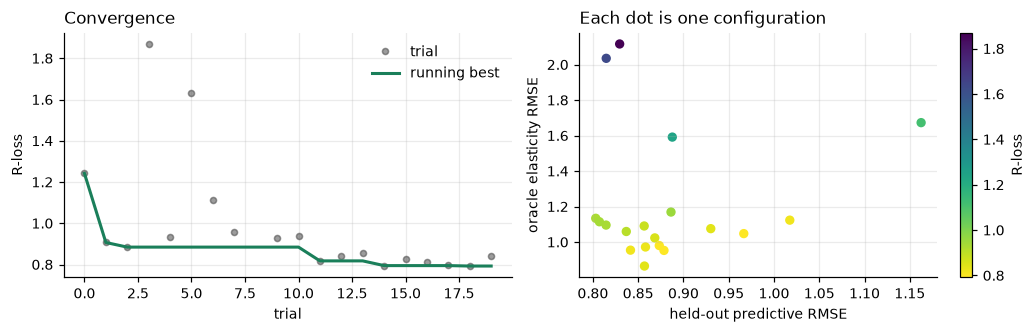

In [13]:
r_demo = tune("lgbm_demand", syn, objective="rloss", n_trials=20, scorer=scorer,
              truth_col="true_elasticity", seed=1)
h = tuning_history(r_demo)
print(f"{r_demo['n_complete']} completed, {r_demo['n_pruned']} pruned")

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.1))
ax[0].plot(h.trial, h.rloss, "o", ms=4, color=INK, alpha=.5, label="trial")
ax[0].plot(h.trial, h.running_best, "-", color=GOOD, lw=2, label="running best")
ax[0].set_xlabel("trial"); ax[0].set_ylabel("R-loss"); ax[0].legend(frameon=False)
ax[0].set_title("Convergence", loc="left")
sc = ax[1].scatter(h.rmse, h.oracle, c=h.rloss, cmap="viridis_r", s=26)
ax[1].set_xlabel("held-out predictive RMSE"); ax[1].set_ylabel("oracle elasticity RMSE")
ax[1].set_title("Each dot is one configuration", loc="left")
fig.colorbar(sc, ax=ax[1], label="R-loss")
fig.tight_layout()

The right-hand panel is the summary of the whole notebook. If predictive RMSE were a
good guide, the cloud would run bottom-left to top-right. The colouring shows where R-loss
sends the search instead.

## 3.6 Nested cross-validation

One tuned score is optimistically biased: the winner is the **maximum over many noisy
estimates**, so it carries the maximum's upward bias. Nested CV removes it — tune inside
each outer fold, score on the outer block the search never touched.

The gap between the two is itself the interesting number. It says how much of the apparent
gain was selection noise, and therefore how much to trust a leaderboard built from tuned
scores.

In [14]:
nest = pd.concat([nested_cv(m, syn, objective="rloss", n_trials=8, n_outer=2,
                            truth_col="true_elasticity", seed=0)
                  for m in ["dml_partialling", "lgbm_demand", "twoway_fe"]],
                 ignore_index=True)
summary = (nest.groupby("model")
               .agg(inner_rloss=("inner_best", "mean"),
                    outer_rloss=("outer_rloss", "mean"),
                    outer_oracle=("outer_oracle", "mean"),
                    outer_bias=("outer_oracle_bias", "mean")))
summary["optimism"] = summary.outer_rloss - summary.inner_rloss
summary.style.format("{:+.4f}")

,inner_rloss,outer_rloss,outer_oracle,outer_bias,optimism
model,,,,,
dml_partialling,+0.7311,+0.6874,+0.8044,-0.3981,-0.0437
lgbm_demand,+0.7868,+0.7686,+1.0776,-0.6792,-0.0183
twoway_fe,+0.7703,+0.7329,+1.1340,-0.8892,-0.0374


A positive `optimism` is the selection bias made visible: the tuned score was better
than the honest one by that much. Report the outer column.

## 3.7 Doing it for real

On the real panel there is no oracle. Everything above was to establish, in a world where
we *could* check, that the R-loss is the objective to use. Now we use it.

In [15]:
real = real_frame(N_PRODUCTS)
real_scorer = CausalScorer(real, RollingOriginSplit(n_splits=4, horizon=8,
                                                   min_train_weeks=30), seed=0)
tuned = {}
for name in ["twoway_fe", "lgbm_demand", "dml_partialling", "r_learner",
             "shrunk_per_product"]:
    r = tune(name, real, objective="rloss", n_trials=12, scorer=real_scorer, seed=0)
    tuned[name] = r
    print(f"{name:20s} rloss={r['best_metrics']['rloss']:.4f}  "
          f"skill={r['best_metrics']['rloss_skill']:+.4f}  "
          f"vs-const={r['best_metrics']['rloss_vs_constant']:+.4f}  "
          f"eps={r['best_metrics']['avg_eps']:+.4f}")

pd.to_pickle({k: v["best_params"] for k, v in tuned.items()},
             "../experiments/out/03_tuned_params_real.pkl")
pd.DataFrame([{"model": k, **v["best_metrics"]} for k, v in tuned.items()]) \
  .sort_values("rloss").style.format({c: "{:+.4f}" for c in
      ["rmse", "rloss", "rloss_skill", "rloss_vs_constant", "avg_eps", "eps_sd"]}) \
  .hide(axis="index")

twoway_fe            rloss=2.3323  skill=+0.1142  vs-const=-0.0026  eps=+1.6466


lgbm_demand          rloss=2.5964  skill=+0.0173  vs-const=-0.1116  eps=+1.6154


dml_partialling      rloss=2.3457  skill=+0.1104  vs-const=-0.0071  eps=+1.2669


r_learner            rloss=2.3301  skill=+0.1173  vs-const=+0.0010  eps=+1.3953


shrunk_per_product   rloss=2.3326  skill=+0.1134  vs-const=-0.0035  eps=+1.6442


model,rmse,rloss,rloss_skill,rloss_vs_constant,avg_eps,eps_sd
r_learner,+1.2288,+2.3301,+0.1173,+0.0010,+1.3953,+0.4845
twoway_fe,+15.9574,+2.3323,+0.1142,-0.0026,+1.6466,+0.0000
shrunk_per_product,+1.2427,+2.3326,+0.1134,-0.0035,+1.6442,+0.0015
dml_partialling,+1.1521,+2.3457,+0.1104,-0.0071,+1.2669,+0.0000
lgbm_demand,+1.6640,+2.5964,+0.0173,-0.1116,+1.6154,+1.1383


In [16]:
for name, r in tuned.items():
    print(f"\n{name}:")
    for k, v in r["best_params"].items():
        print(f"    {k:24s} {v}")


twoway_fe:
    add_controls             True
    n_iter                   10
    collinear_tol            0.013728041266163145

lgbm_demand:
    n_estimators             700
    learning_rate            0.11387317092169064
    num_leaves               63
    min_child_samples        52
    subsample                0.7118273996694524
    colsample_bytree         0.7875364678399936
    reg_lambda               0.042220489831498315
    delta                    0.17645954556097573

dml_partialling:
    n_estimators             450
    learning_rate            0.06912670683424535
    num_leaves               8
    min_child_samples        72
    subsample                0.8060478613612108
    colsample_bytree         0.7701603981248542
    reg_lambda               45.971478464161336
    n_folds                  4

r_learner:
    n_estimators             650
    learning_rate            0.03396540216391729
    num_leaves               35
    min_child_samples        103
    subsample       

### Reading `rloss_vs_constant` on real data

This column is the one to look at, and it is usually sobering. It asks whether the model
beats *a single elasticity applied to every product*, judged on held-out data. A value at
or below zero means the heterogeneity the model reports is not earning its keep — the model
may still be useful for its average, but its per-product numbers should not drive
per-product decisions.

That is the bridge to notebook 4, which turns these scores into the two things a business
can act on: **is the heterogeneity real**, and **what is it worth**.

## 3.8 What we established

1. Predictive loss and elasticity accuracy have their optima in different places, and the
   gap is large enough to change conclusions. At full scale the S-learner's elasticity error
   falls **62%** (2.60 → 0.99) purely by changing what the search minimises.
2. The **R-loss** is computable from observed data, is minimised at the true elasticity
   function, and is model-agnostic, so it can compare a fixed-effects regression with a
   boosted tree on the same axis. 6 of 7 models improve under it.
3. The decisive test is **rank correlation with the oracle across a search**, not the level
   of the score. Median rho: **+0.903** for the R-loss, **−0.204** for predictive RMSE,
   which *anti-ranks for 4 of 7 models* — steering the search away from the truth.
4. **The R-loss inherits the bias of the nuisance model that scores it.** For an already
   orthogonal estimator it has little to add and can mislead at the margin. Judge the stakes
   by `oracle_spread` before spending a search budget.
5. Report **nested-CV** numbers; the gap to the tuned score is the selection bias.
6. The nuisance models used for scoring must be fixed across candidates, or the comparison
   is rigged.
7. Fix your thread count. `n_jobs=-1` was a 340× slowdown here.

**Next:** `04_comparison_and_selection.ipynb` — is the heterogeneity real, and what is it
worth?